In [1]:
# Tự nạp lại raw_feature.py mỗi khi sửa, không cần restart kernel
%load_ext autoreload
%autoreload 2
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from feature_node import build_entity_features, load_data

In [2]:
df=load_data()
asof, log_cols = build_entity_features(df)
feat = asof[asof["split"] == "train"].drop(columns=["split", "ori_idx"])
print("feat shape:", feat.shape)

feat shape: (3046861, 60)


In [10]:
profile = pd.DataFrame({
    "max":     feat.max(),
    "in_0_1":  (feat.min() >= 0) & (feat.max() <= 1),  # True = ratio nằm gọn trong [0,1]
    "skew":    feat.skew(),
}).round(3)

print("Cột nằm trong [0,1]")
print(profile.index[profile["in_0_1"]].tolist())
print("\n== Bảng đầy đủ ==")
profile.sort_values("skew", ascending=False)

Cột nằm trong [0,1]
['src_ratio_cross_bank', 'src_ratio_cross_curcy', 'src_ratio_ACH', 'src_ratio_Bitcoin', 'src_ratio_Cash', 'src_ratio_Cheque', 'src_ratio_Credit Card', 'src_ratio_Reinvestment', 'src_ratio_Wire', 'src_first_seen', 'dest_ratio_cross_bank', 'dest_ratio_cross_curcy', 'dest_ratio_ACH', 'dest_ratio_Bitcoin', 'dest_ratio_Cash', 'dest_ratio_Cheque', 'dest_ratio_Credit Card', 'dest_ratio_Reinvestment', 'dest_ratio_Wire', 'dest_first_seen', 'pair_ratio_cross_bank', 'pair_ratio_cross_curcy', 'pair_ratio_ACH', 'pair_ratio_Bitcoin', 'pair_ratio_Cash', 'pair_ratio_Cheque', 'pair_ratio_Credit Card', 'pair_ratio_Reinvestment', 'pair_ratio_Wire', 'pair_first_seen']

== Bảng đầy đủ ==


,max,in_0_1,skew
pair_min,4.536185e+11,False,971.877
pair_mean,5.064764e+11,False,855.809
dest_min,1.402124e+11,False,674.485
pair_max,5.593344e+11,False,615.207
src_min,9.094788e+10,False,585.513
pair_sum,1.012953e+12,False,454.785
pair_std,6.870347e+10,False,352.890
src_mean,1.466779e+11,False,252.028
dest_max,6.260355e+11,False,207.270
dest_sum,1.013051e+12,False,206.600


In [11]:
report = pd.DataFrame({
    "skew_raw":   feat.skew(),
    "skew_log1p": np.log1p(feat).skew(), 
}).sort_values("skew_raw", ascending=False)

report.round(2)

c:\Users\LENOVO\anaconda3\Lib\site-packages\pandas\core\nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)


,skew_raw,skew_log1p
pair_min,971.88,0.39
pair_mean,855.81,0.28
dest_min,674.49,0.93
pair_max,615.21,0.25
src_min,585.51,1.10
pair_sum,454.79,0.12
pair_std,352.89,0.90
src_mean,252.03,-0.43
dest_max,207.27,-0.52
dest_sum,206.60,-0.60


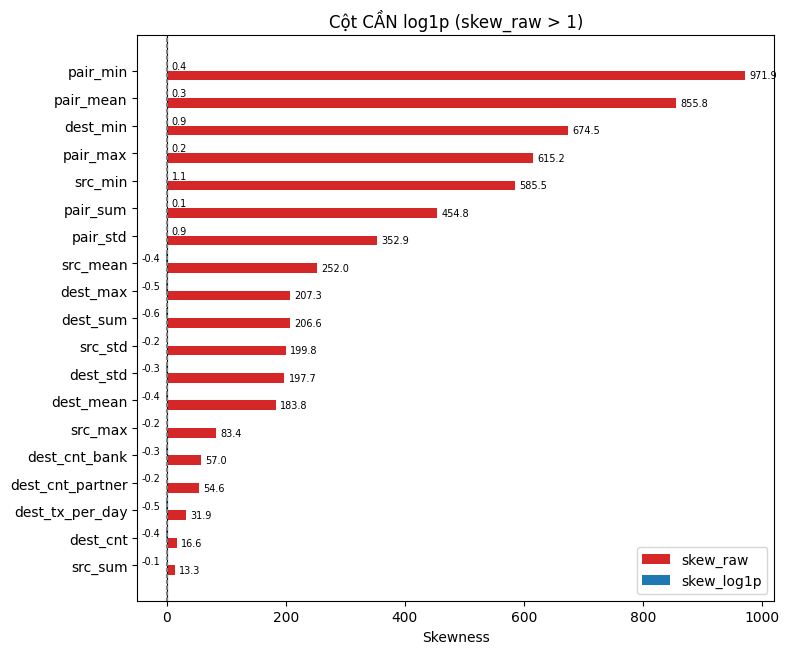

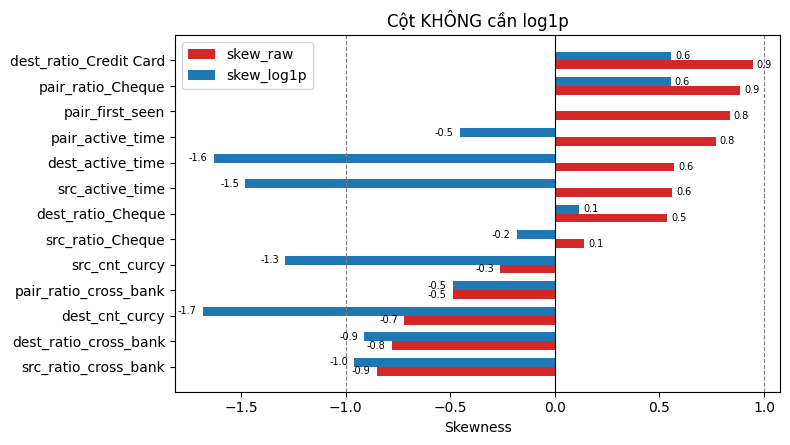

In [15]:
# Tách 2 nhóm: cột CẦN xử lý log1p (skew_raw > 1, min >= 0) vs cột KHÔNG cần
skewed     = report[(report["skew_raw"] > 1)]
not_skewed = report.drop(index=skewed.index)

assert set(skewed.index).isdisjoint(not_skewed.index)  # đảm bảo không cột nào bị trùng ở cả 2 hình

def plot_skew(df, title):
    fig, ax = plt.subplots(figsize=(8, max(3, len(df) * 0.35)))
    y = np.arange(len(df))
    height = 0.35

    bars_raw = ax.barh(y + height/2, df["skew_raw"], height, label="skew_raw", color="#d62728")
    bars_log = ax.barh(y - height/2, df["skew_log1p"], height, label="skew_log1p", color="#1f77b4")

    for bars in (bars_raw, bars_log):
        for b in bars:
            w = b.get_width()
            ax.annotate(f"{w:.1f}",
                        (w, b.get_y() + b.get_height() / 2),
                        textcoords="offset points",
                        xytext=(3 if w >= 0 else -18, 0),
                        va="center", fontsize=7)

    ax.axvline(0, color="black", linewidth=0.8)
    ax.axvline(1, color="gray", linestyle="--", linewidth=0.8)
    ax.axvline(-1, color="gray", linestyle="--", linewidth=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(df.index)
    ax.invert_yaxis()
    ax.set_xlabel("Skewness")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()
cut_at = skewed.index.get_loc("src_sum")
skewed_plot = skewed.iloc[:cut_at + 1]
plot_skew(skewed_plot, "Cột CẦN log1p (skew_raw > 1)")
plot_skew(not_skewed, "Cột KHÔNG cần log1p")


In [17]:
# Bảng skew: thô vs sau log1p
ratio_cols=[]
for i in profile.index:
    if profile.loc[i,"in_0_1"]==True:
        ratio_cols.append(i)
cand   = [c for c in feat.columns if c not in ratio_cols]              #cand là cột chứa cột cần xử lý
nonneg = [c for c in cand if feat[c].min() >= 0]                                 # log1p chỉ hợp lệ khi >= 0

report = pd.DataFrame({
    "min":        feat[cand].min(),
    "skew_raw":   feat[cand].skew(),
    "skew_log1p": np.log1p(feat[nonneg]).skew(),
}).sort_values("skew_raw", ascending=False)

report.round(2)

,min,skew_raw,skew_log1p
pair_min,0.0,971.88,0.39
pair_mean,0.0,855.81,0.28
dest_min,0.0,674.49,0.93
pair_max,0.0,615.21,0.25
src_min,0.0,585.51,1.10
pair_sum,0.0,454.79,0.12
pair_std,0.0,352.89,0.90
src_mean,0.0,252.03,-0.43
dest_max,0.0,207.27,-0.52
dest_sum,0.0,206.60,-0.60


In [18]:
# Đề xuất cột log1p (lệch phải mạnh + không âm). Vẫn nên nhìn skew_log1p để loại cột bị kéo quá đà.
log1p_cols = report.index[(report["skew_raw"] > 1) & (report["min"] >= 0)].tolist()
print("Đề xuất log1p_cols:")
for c in log1p_cols:
    print(f"  {c:18s} skew_raw={report.loc[c,'skew_raw']:.2f} -> skew_log1p={report.loc[c,'skew_log1p']:.2f}")

Đề xuất log1p_cols:
  pair_min           skew_raw=971.88 -> skew_log1p=0.39
  pair_mean          skew_raw=855.81 -> skew_log1p=0.28
  dest_min           skew_raw=674.49 -> skew_log1p=0.93
  pair_max           skew_raw=615.21 -> skew_log1p=0.25
  src_min            skew_raw=585.51 -> skew_log1p=1.10
  pair_sum           skew_raw=454.79 -> skew_log1p=0.12
  pair_std           skew_raw=352.89 -> skew_log1p=0.90
  src_mean           skew_raw=252.03 -> skew_log1p=-0.43
  dest_max           skew_raw=207.27 -> skew_log1p=-0.52
  dest_sum           skew_raw=206.60 -> skew_log1p=-0.60
  src_std            skew_raw=199.75 -> skew_log1p=-0.19
  dest_std           skew_raw=197.73 -> skew_log1p=-0.27
  dest_mean          skew_raw=183.83 -> skew_log1p=-0.43
  src_max            skew_raw=83.35 -> skew_log1p=-0.15
  dest_cnt_bank      skew_raw=57.04 -> skew_log1p=-0.29
  dest_cnt_partner   skew_raw=54.61 -> skew_log1p=-0.21
  dest_tx_per_day    skew_raw=31.93 -> skew_log1p=-0.48
  dest_cnt           s

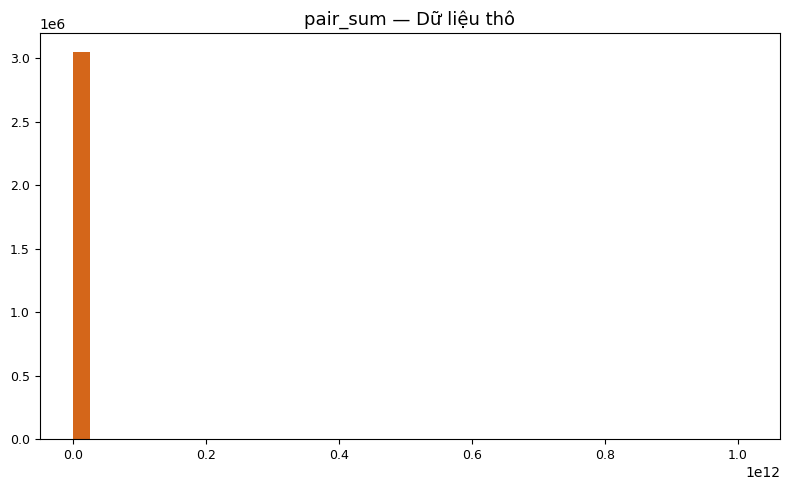

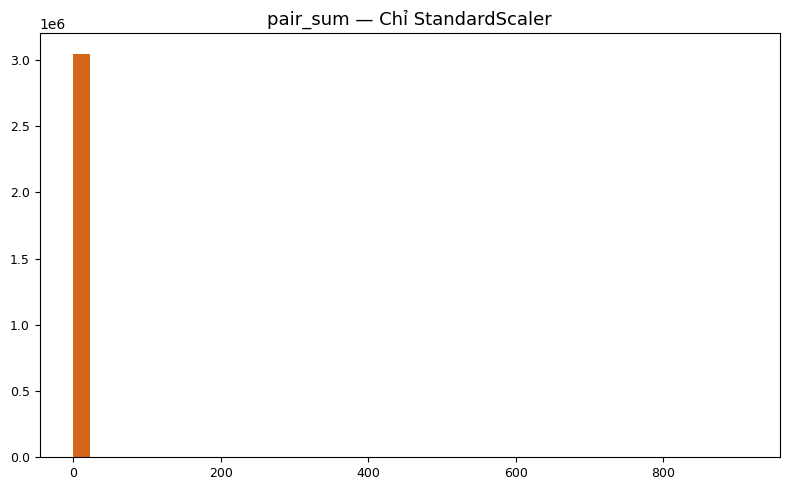

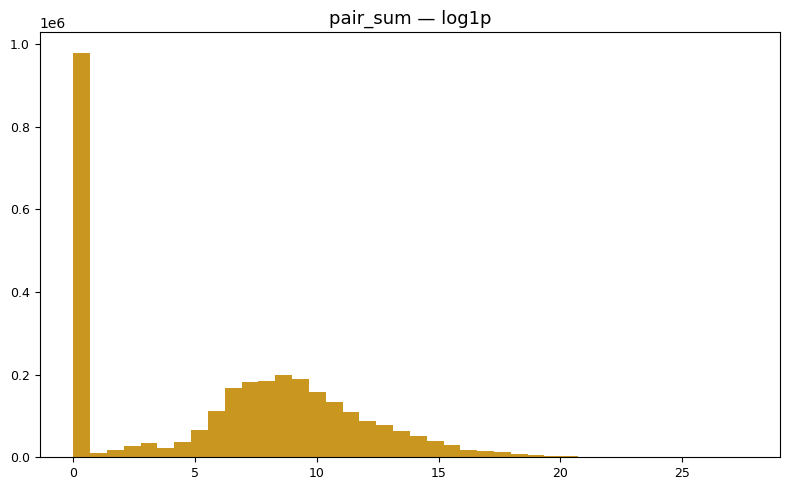

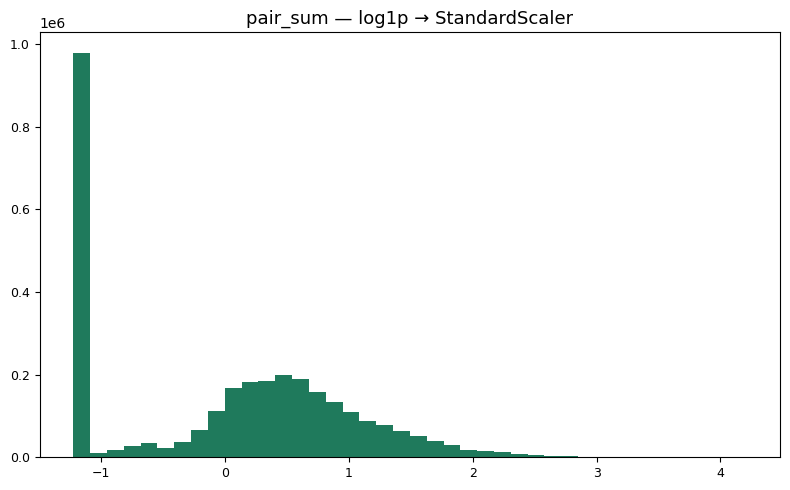

In [23]:
from sklearn.preprocessing import StandardScaler

col = "pair_sum"   # <-- tự đổi tên cột ở đây

x_raw = feat[col].values.astype(float)
x_log = np.log1p(x_raw)
x_raw_scaled = StandardScaler().fit_transform(x_raw.reshape(-1, 1)).ravel()
x_log_scaled = StandardScaler().fit_transform(x_log.reshape(-1, 1)).ravel()

panels = [
    ("Dữ liệu thô",            x_raw,        "#d4661a"),
    ("Chỉ StandardScaler",     x_raw_scaled, "#d4661a"),
    ("log1p",                  x_log,        "#c9971f"),
    ("log1p → StandardScaler", x_log_scaled, "#1f7a5c"),
]

for title, data, color in panels:
    plt.figure(figsize=(8, 5))
    plt.hist(data, bins=40, color=color)
    plt.title(f"{col} — {title}", fontsize=13)
    plt.tick_params(labelsize=9)
    plt.tight_layout()
    plt.show()


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_24096\1283670996.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([feat[col], np.log1p(feat[col])], labels=["raw", "log1p"])


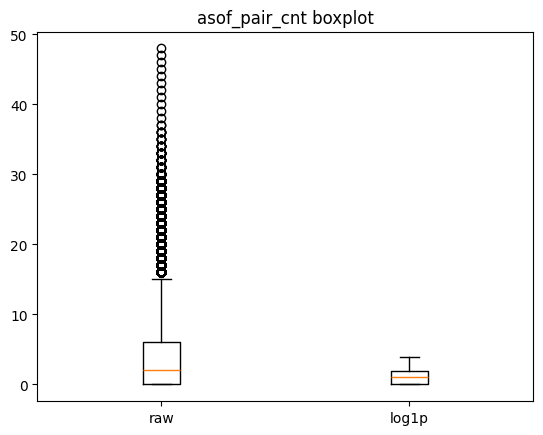

In [9]:
col = "asof_pair_cnt"
plt.boxplot([feat[col], np.log1p(feat[col])], labels=["raw", "log1p"])
plt.title(f"{col} boxplot"); plt.show()